# VolumeDataset Tutorial

This notebook is a comprehensive guide to the `VolumeDataset` class and its 2D slicing functionality in Datamint.

**What you'll learn:**
1. Loading 3D medical volumes from a Datamint project
2. Inspecting resource metadata
3. Accessing full 3D items and visualizing them
4. Slicing volumes along anatomical axes into 2D datasets
5. Working with segmentation masks on slices
6. Pre-processing with **albumentations**
7. Accessing DICOM metadata from resources

## 1. Installation & Imports

Install the `datamint` package if it is not already available, then import all required modules.


In [ ]:
%pip install -U datamint --quiet

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from datamint.dataset import build_dataset
from datamint.dataset import VolumeDataset

## 2. Loading a VolumeDataset

`VolumeDataset` is a PyTorch `Dataset` backed by Datamint. Pass a project name and it will fetch all volumetric resources from that project. Data is loaded lazily — nothing is downloaded until you actually index into the dataset.

In [ ]:
PROJECT_NAME = "your-project-name"  # <-- Replace with your project name

vol_ds = VolumeDataset(
    project=PROJECT_NAME,
    include_unannotated=True,  # Whether to include volumes without any annotations (default: False)
    allow_external_annotations=True,  # Whether to allow annotations from other projects/sources (default: False)
    # return_as_semantic_segmentation=True, # False by default. Converts instance segmentations to semantic segmentation masks.
    # semantic_seg_merge_strategy="union"
)

# alternatively, you can use the build_dataset function that is generic and can be used for both volume and image datasets.
#vol_ds = build_dataset(
#    PROJECT_NAME,
#    include_unannotated=True, 
#    allow_external_annotations=True,
#)

print(vol_ds)
print(f"\nNumber of volumes: {len(vol_ds)}")
print(f"Segmentation labels: {vol_ds.segmentation_labels_set}")
print(f"Image-level labels : {vol_ds.image_labels_set}")

## 3. Inspecting Volume Resources

Each `VolumeDataset` exposes a `.resources` list of `Resource` objects. These carry rich metadata — filenames, modality, DICOM UIDs, size, tags and more.


In [ ]:
vol_ds.resources[0]

## 4. Accessing 3D Volume Items

Indexing into `VolumeDataset` returns a dictionary with:
- `'image'` — `np.ndarray` of shape `(C, D, H, W)`
- `'metainfo'` — dict with file-level metadata
- `'masks'` — dict `{annotator_id -> np.ndarray}` of shape `(#instances, D, H, W)` (when `return_segmentations=True`)
- `'image_labels'` — dict `{annotator_id -> Tensor}` of binary label vectors


In [ ]:
item = vol_ds[0]  # loads and caches the first volume

img = item['image']  # shape: (C, D, H, W)
print(f"Image shape : {img.shape}  (C, D, H, W)")
print(f"Patient ID: {item['metainfo'].get('PatientID')}")

if item.get('masks'):
    for author, seg in item['masks'].items():
        print(f"\nSegmentation by '{author}': shape={seg.shape}  (instances, D, H, W)")

In [ ]:
from datamint.utils.visualization import show

show(img[0, 0], normalize=True)

## 5. Slicing Volumes into 2D Datasets

`VolumeDataset.slice()` returns a `SlicedVolumeDataset` that expands every 3D volume into individual 2D slices. Each slice becomes one dataset item with shape `(C, H, W)`.

Supported axes:
- `'axial'` (or `0`) — superior–inferior slices
- `'coronal'` (or `1`) — anterior–posterior slices
- `'sagittal'` (or `2`) — left–right slices

In [15]:
# Create a sliced dataset for each anatomical plane
axial_ds    = vol_ds.slice(axis='axial')
# coronal_ds  = vol_ds.slice(axis='coronal')
# sagittal_ds = vol_ds.slice(axis='sagittal')

print(f"Volumes in parent dataset : {len(vol_ds)}")
print(f"Total Axial slices        : {len(axial_ds)}")


Volumes in parent dataset : 12
Total Axial slices        : 6144


## 6. Iterating Over 2D Slices

`SlicedVolumeDataset` is a standard PyTorch `Dataset`, so it works seamlessly with `DataLoader`. Each item is a dict with at least:
- `'image'` — `np.ndarray` or `Tensor` of shape `(C, H, W)`
- `'image_labels'` — dict of annotator → label tensor


Slice image shape: (1, 512, 94)  (C, H, W)


/home/luan/Desktop/Datamint/Codes/datamint-python-api/datamint/env/lib/python3.12/site-packages/torchvision/transforms/functional.py:282: RuntimeWarning: invalid value encountered in cast
  npimg = (npimg * 255).astype(np.uint8)


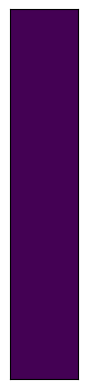

In [18]:
# Single-item access
slice_item = axial_ds[1]
slice_img = slice_item['image']  # shape: (C, H, W)
print(f"Slice image shape: {slice_img.shape}  (C, H, W)")
show(slice_img[0], normalize=True)

## 7. Accessing Segmentation Masks

When `return_segmentations=True` (the default), `SlicedVolumeDataset.__getitem__` returns:

- `item['masks']` — dict `{annotator_id -> np.ndarray}` of shape `(#instances, H, W)` (instance masks, boolean)
- `item['mask_labels']` — dict `{annotator_id -> np.ndarray}` of integer class codes per instance

if `return_as_semantic_segmentation=True`, then instance masks are converted to a single semantic mask:
- `item['masks']` — `Tensor` of shape `(num_classes+1, H, W)` with one-hot encoding (background=0, classes start at 1).


In [ ]:
seg_ds = vol_ds.slice(axis='axial')  # return_segmentations is inherited from vol_ds

seg_item_idx = 3
item = seg_ds[seg_item_idx]
img_slice = item['image']        # (C, H, W)
segs      = item['masks']  # dict {author -> (#instances, H, W)}
seg_labels = item.get('mask_labels', {})

print(f"Slice index : {seg_ds.resources[seg_item_idx].slice_index}")
for author, masks in segs.items():
    labels = seg_labels.get(author, [])
    if (masks==0).all():  # Check if there are any non-empty masks
        print(f"  Author '{author}': No segmentation instances (all masks are empty).")
    else:
        print(f"  Author '{author}': {masks.shape[0]} instance(s), labels={labels.tolist()}")


## 8. Pre-processing with Albumentations

Pass an **albumentations** transform via `alb_transform` to apply augmentations on-the-fly. The library is slice-aware: the same geometric transform is replayed on all segmentation masks so spatial consistency is guaranteed.

> **Important:** albumentations expects images in `(H, W, C)` format. `VolumeDataset` / `SlicedVolumeDataset` handles the transposition automatically.


In [20]:
import albumentations as A

# Define an augmentation pipeline for training
train_transform = A.Compose([
    # A.RandomCrop(height=256, width=256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
])

# Build a dataset with transforms
augmented_vol_ds = VolumeDataset(
    project=PROJECT_NAME,
    return_segmentations=True,
    alb_transform=train_transform,
)
augmented_ds = augmented_vol_ds.slice(axis='axial')

# You can also set or swap the transform after construction
augmented_ds.set_transform(train_transform)

print(f"Augmented dataset: {len(augmented_ds)} slices")


Augmented dataset: 6144 slices


In [ ]:
# Visualize before/after augmentation on the same slice index
IDX = 3

# Without augmentation (original)
orig_item = axial_ds[IDX]
orig_img  = orig_item['image']  # (C, H, W)

# With augmentation (may be cropped / flipped)
aug_item  = augmented_ds[IDX]
aug_img   = aug_item['image']   # (C, H_crop, W_crop)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(orig_img[0], cmap='gray')
axes[0].set_title(f"Original  {orig_img.shape[1:]}")
axes[0].axis('off')

axes[1].imshow(aug_img[0], cmap='gray')
axes[1].set_title(f"Augmented {aug_img.shape[1:]}")
axes[1].axis('off')

plt.suptitle("Before vs After Augmentation", fontsize=13)
plt.tight_layout()
plt.show()


## 9. Accessing DICOM Metadata

Every `Resource` (and by delegation, every `SlicedVolumeResource`) exposes structured metadata through its `.metadata` dict and top-level shortcut properties such as `instance_uid`, `series_uid`, `study_uid`, and `patient_id`.

For richer DICOM tag access, you can load the raw pydicom `Dataset` directly via `resource.fetch_file_data(auto_convert=True)` for DICOM series resources.


In [ ]:
# --- High-level shortcut properties available on every Resource ---
for i, resource in enumerate(vol_ds.resources[:2]):
    print(f"\nResource {i}: {resource.filename}")
    print(f"  modality      : {resource.modality}")
    print(f"  instance_uid  : {resource.metadata['instance_uid']}")
    print(f"  series_uid    : {resource.metadata['series_uid']}")
    print(f"  study_uid     : {resource.metadata['study_uid']}")
    print(f"  patient_id    : {resource.metadata['patient_id']}")
    print(f"  metadata keys : {list(resource.metadata.keys())}")

---

## Summary

| Feature | Code |
|---|---|
| Load 3D dataset | `VolumeDataset(project='...')` |
| Inspect resources | `dataset.resources[i].filename`, `.modality`, `.tags` |
| Access 3D item | `dataset[i]['image']` → `(C, D, H, W)` |
| Slice to 2D | `vol_ds.slice(axis='axial')` |
| 2D item | `sliced_ds[i]['image']` → `(C, H, W)` |
| Segmentation masks | `sliced_ds[i]['masks']` → `{author -> (#inst, H, W)}` |
| Apply transforms | `VolumeDataset(..., alb_transform=my_transform)` |
| DICOM tags | `resource.fetch_file_data(auto_convert=True)` → pydicom Dataset |
| Resource metadata | `resource.metadata` |
| Resource tags | `resource.tags` |
